# v05 — ML Training: Random Forest (XAUUSD M5)

**Kenapa pindah dari rule-based ke ML:** v02-v04 memakai scoring rule-based dengan threshold yang
di-*grid search* langsung di data yang sama untuk memilih parameter (mis. `MIN_SIGNAL_SCORE=9`,
`TP=12/SL=6`, dst). Ini rawan **overfitting** — kita mencoba puluhan kombinasi dan memilih yang
hasilnya terbaik DI DATA YANG SAMA, tanpa validasi out-of-sample yang ketat. v05 mengganti pendekatan
ini dengan model ML (Random Forest) yang dilatih & divalidasi dengan disiplin time-series yang benar.

**Desain anti-overfit di notebook ini:**
1. **Fitur**: seluruh 73 indikator M5 + 76 indikator H1 (149 fitur) — semua *backward-looking*
   (rolling/EWM dari data historis), tidak ada kebocoran informasi masa depan ke fitur
2. **Label**: simulasi TP=SL=1×ATR (symmetric) dalam 12 candle ke depan — lihat sel di bawah kenapa
   symmetric, bukan TP12/SL6 asimetris seperti v02-v04
3. **Split time-based 3-bagian**: train (2019-2023) / validation (2024) / test (2025-2026) — test
   set benar-benar tidak pernah dilihat untuk keputusan apa pun (beda dengan v02-v04 yang tuning-nya
   pakai data 2025-2026 juga)
4. **Walk-forward validation** di dalam training set sebelum fit model final
5. **Threshold probabilitas dipilih di validation, dievaluasi SEKALI di test** — bukan grid search
   langsung di test set (lihat catatan di bagian split)

**Riwayat revisi (dicatat supaya jelas apa yang sudah dicoba & kenapa diganti):**
- **Run 1** (TP12/SL6 asimetris, threshold dipilih di test set, position sizing compounding 1% risk):
  win rate 78%, PF 5.38, TAPI net PnL meledak ke jutaan dolar dari modal $100 — bug compounding tanpa
  cap. 91% dari sampel yang "menang" sebenarnya TIMEOUT (bukan TP resmi).
- **Run 2** (fixed lot, threshold masih dipilih di test): profit factor & PnL jadi masuk akal secara
  skala, tapi win rate 87.6% dan PF 12 masih janggal — investigasi menemukan **99.8% trade adalah
  SELL** karena label imbalance (78.8% data berlabel SELL, akibat SL 6pt jauh lebih dekat/gampang
  "kena duluan" dibanding TP 12pt yang lebih jauh — ini soal geometri TP/SL, bukan XAUUSD yang
  genuinely bearish 79% waktu). Model bukan belajar arah, tapi belajar "kapan momentum SELL kuat".
- **Run 3 (versi ini)**: dua perbaikan sekaligus — (a) split 3-bagian dgn threshold dipilih HANYA di
  validation, (b) **label symmetric TP=SL=1×ATR** (dari titik ini ke bawah) supaya distribusi label
  seimbang dan model belajar ARAH murni, bukan bias geometri RR. Ini persis pendekatan yang
  didokumentasikan `quant-trader-ai` (`CandlePredictor._make_labels`) untuk alasan yang sama.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import json
import math

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit

STRATEGY_NAME = "m5_scalping"
VERSION = "v05"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
PROCESSED_OUT_DIR = PROCESSED_DIR / VERSION
MODEL_DIR = PROJECT_ROOT / "models" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)
RANDOM_STATE = 42

## 1. Load dataset M5 + H1 (gabung, sama seperti v02-v04)

In [2]:
df = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

df_h1 = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
df_h1["datetime"] = pd.to_datetime(df_h1["datetime"])
df_h1 = df_h1.sort_values("datetime").reset_index(drop=True)

df_h1_shifted = df_h1.copy()
df_h1_shifted["h1_available_at"] = df_h1_shifted["datetime"] + pd.Timedelta(hours=1)
h1_value_cols = [c for c in df_h1_shifted.columns if c != "h1_available_at"]
df_h1_shifted = df_h1_shifted[["h1_available_at", *h1_value_cols]].rename(
    columns={c: f"h1_{c}" for c in h1_value_cols}
)

df = pd.merge_asof(
    df.sort_values("datetime"),
    df_h1_shifted.sort_values("h1_available_at"),
    left_on="datetime",
    right_on="h1_available_at",
    direction="backward",
)

print("M5 + konteks H1:", df.shape)
print(df["datetime"].min(), "->", df["datetime"].max())

M5 + konteks H1: (518403, 151)
2019-01-01 23:00:00+00:00 -> 2026-08-06 12:35:00+00:00


## 2. Buat label: simulasi TP=SL=1×ATR (symmetric) dalam 12 candle ke depan

**Kenapa symmetric, bukan TP12/SL6 asimetris:** dengan TP12/SL6 (RR 1:2), SL yang 2x lebih dekat ke
entry jauh lebih sering "kena duluan" drpd TP yang 2x lebih jauh — murni soal geometri jarak, bukan
market yang genuinely condong ke satu arah. Ini menghasilkan label imbalance parah (terbukti di run
sebelumnya: 78.8% SELL) yang bikin model condong memprediksi kelas mayoritas dengan confidence
tinggi, bukan belajar arah yang genuine.

**Solusi:** TP dan SL sama besar (1×ATR candle saat itu, adaptif terhadap volatilitas). Untuk tiap
candle i: lihat candle i+1 s.d. i+12. Kalau `high` menembus `close[i]+ATR` SEBELUM `low` menembus
`close[i]-ATR` → label 1 (BUY). Sebaliknya → label 0 (SELL). Row "close call" (selisih index hit
TP/SL ≤ 2 candle) dibuang sbg ambigu (mengikuti `quant-trader-ai`) — kalau margin kemenangan cuma
1-2 candle, itu terlalu random utk dijadikan sinyal training yang bersih.

In [3]:
LOOKAHEAD = 12
CLOSE_CALL_MARGIN = 2  # candle -- selisih hit index <= ini dianggap ambigu, dibuang

close = df["close"].to_numpy(dtype=np.float64)
high = df["high"].to_numpy(dtype=np.float64)
low = df["low"].to_numpy(dtype=np.float64)
atr = df["atr"].to_numpy(dtype=np.float64)
n = len(df)

labels = np.full(n, np.nan)

for i in range(n - LOOKAHEAD):
    entry: float = close[i]
    dist: float = atr[i]
    if not np.isfinite(dist) or dist <= 0:
        continue

    tp_buy = entry + dist
    sl_buy = entry - dist

    window_high = high[i + 1 : i + 1 + LOOKAHEAD]
    window_low = low[i + 1 : i + 1 + LOOKAHEAD]

    tp_hit_idx = np.argmax(window_high >= tp_buy) if (window_high >= tp_buy).any() else -1
    sl_hit_idx = np.argmax(window_low <= sl_buy) if (window_low <= sl_buy).any() else -1

    if tp_hit_idx == -1 and sl_hit_idx == -1:
        continue  # timeout, tidak ada yang kena -> ambigu, dibuang
    elif tp_hit_idx != -1 and sl_hit_idx == -1:
        labels[i] = 1  # BUY profit
    elif sl_hit_idx != -1 and tp_hit_idx == -1:
        labels[i] = 0  # SELL profit
    elif abs(tp_hit_idx - sl_hit_idx) <= CLOSE_CALL_MARGIN:
        continue  # close call -- margin kemenangan terlalu tipis, ambigu, dibuang
    else:
        labels[i] = 1 if tp_hit_idx < sl_hit_idx else 0

df["label"] = labels
print("Distribusi label (sebelum drop NaN):")
print(df["label"].value_counts(dropna=False))
print(f"\n% ambigu/dibuang: {df['label'].isna().mean()*100:.1f}%")

Distribusi label (sebelum drop NaN):
label
1.0    231275
0.0    230332
NaN     56796
Name: count, dtype: int64

% ambigu/dibuang: 11.0%


## 3. Feature engineering: semua kolom indikator M5 + H1 (exclude OHLCV mentah & metadata waktu)

In [4]:
EXCLUDE_COLS = {
    "timestamp", "datetime", "open", "high", "low", "close", "volume", "label",
    "h1_available_at", "h1_timestamp", "h1_datetime", "h1_open", "h1_high", "h1_low",
    "h1_close", "h1_volume",
}
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]
print(f"Total fitur: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Total fitur: 136
['ema_9', 'ema_20', 'ema_50', 'ema_200', 'sma_10', 'sma_20', 'sma_50', 'sma_200', 'macd', 'macd_signal', 'histogram', 'atr', 'di_pos', 'di_neg', 'adx', 'supertrend', 'supertrend_dir', 'supertrend_flip', 'psar', 'psar_dir', 'ichi_tenkan', 'ichi_kijun', 'ichi_span_a', 'ichi_span_b', 'ichi_cloud_top', 'ichi_cloud_bot', 'ichi_cloud_bull', 'ichi_tk_bull', 'ichi_tk_bear', 'rsi', 'stoch_k', 'stoch_d', 'cci', 'williams_r', 'mfi', 'bb_mid', 'bb_upper', 'bb_lower', 'bb_pct', 'obv', 'obv_ema', 'vwap', 'fib_swing_high', 'fib_swing_low', 'fib_236', 'fib_382', 'fib_500', 'fib_618', 'fib_786', 'rsi_bull_div', 'rsi_bear_div', 'rsi_hid_bull', 'rsi_hid_bear', 'bull_chain', 'bear_chain', 'close_slope', 'fvg_bull', 'fvg_bear', 'ob_bull', 'ob_bear', 'bos_bull', 'bos_bear', 'choch_bull', 'choch_bear', 'liq_bull_sweep', 'liq_bear_sweep', 'candle_pat', 'candle_ex', 'h1_ema_9', 'h1_ema_20', 'h1_ema_50', 'h1_ema_200', 'h1_sma_10', 'h1_sma_20', 'h1_sma_50', 'h1_sma_200', 'h1_macd', 'h1_macd_sign

In [5]:
# Drop baris dengan label NaN (ambigu) ATAU fitur NaN (warm-up period indikator)
df_ml = df.dropna(subset=["label", *FEATURE_COLS]).reset_index(drop=True)
df_ml["label"] = df_ml["label"].astype(int)

print(f"Baris awal: {len(df):,}")
print(f"Baris setelah drop NaN (label ambigu + warm-up indikator): {len(df_ml):,}")
print(f"\nDistribusi label final:")
print(df_ml["label"].value_counts(normalize=True).round(3))

Baris awal: 518,403
Baris setelah drop NaN (label ambigu + warm-up indikator): 459,710

Distribusi label final:
label
1    0.501
0    0.499
Name: proportion, dtype: float64


## 4. Split time-based 3-bagian: train / validation / test

**Perbaikan penting dari run sebelumnya:** run pertama memilih `prob_threshold` dengan grid search
LANGSUNG di test set (2025-2026) — ini bentuk data snooping yang sama persis dengan kritik terhadap
v02-v04 (memilih parameter berdasarkan performa di data yang dilaporkan sebagai hasil akhir). Threshold
0.75 yang dipilih dengan cara itu menghasilkan win rate 78% yang terbukti tidak realistis setelah
diinvestigasi (didorong oleh label imbalance: 78.8% data berlabel SELL, sehingga model condong
memprediksi SELL dengan percaya diri tinggi — bukan edge dua arah yang genuine).

**Perbaikan:** split jadi 3 — train (2019-2023), validation (2024), test (2025-2026). Threshold
probabilitas dipilih dari performa di **validation** set, baru dievaluasi SEKALI (tanpa grid search
lagi) di **test** set. Test set benar-benar tidak pernah dilihat untuk keputusan apa pun.

In [6]:
VAL_START = "2024-01-01"
TEST_START = "2025-01-01"

train_df = df_ml[df_ml["datetime"] < VAL_START].reset_index(drop=True)
val_df = df_ml[(df_ml["datetime"] >= VAL_START) & (df_ml["datetime"] < TEST_START)].reset_index(drop=True)
test_df = df_ml[df_ml["datetime"] >= TEST_START].reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLS], train_df["label"]
X_val, y_val = val_df[FEATURE_COLS], val_df["label"]
X_test, y_test = test_df[FEATURE_COLS], test_df["label"]

print(f"Train     : {len(train_df):,} baris ({train_df['datetime'].min()} -> {train_df['datetime'].max()})")
print(f"Validation: {len(val_df):,} baris ({val_df['datetime'].min()} -> {val_df['datetime'].max()})")
print(f"Test      : {len(test_df):,} baris ({test_df['datetime'].min()} -> {test_df['datetime'].max()})")
print(f"\nLabel balance train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Label balance val  : {y_val.value_counts(normalize=True).round(3).to_dict()}")
print(f"Label balance test : {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train     : 309,315 baris (2019-01-14 15:00:00+00:00 -> 2023-12-29 21:55:00+00:00)
Validation: 53,623 baris (2024-01-01 23:05:00+00:00 -> 2024-12-30 23:55:00+00:00)
Test      : 96,772 baris (2025-01-01 23:00:00+00:00 -> 2026-08-06 11:35:00+00:00)

Label balance train: {0: 0.501, 1: 0.499}
Label balance val  : {1: 0.512, 0: 0.488}
Label balance test : {1: 0.5, 0: 0.5}


## 5. Walk-forward validation di dalam training set (2019-2023)

Sebelum fit model final, cek konsistensi performa antar-periode pakai `TimeSeriesSplit` 5-fold —
tiap fold, train di masa lalu, validasi di periode setelahnya (tidak pernah validasi di masa lalu
dari train, cocok untuk time-series).

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
wf_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    fold_dates_train = train_df["datetime"].iloc[train_idx]
    fold_dates_val = train_df["datetime"].iloc[val_idx]

    model_fold = RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=50,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
    )
    model_fold.fit(X_fold_train, y_fold_train)

    val_proba = model_fold.predict_proba(X_fold_val)[:, 1]
    val_pred = model_fold.predict(X_fold_val)

    acc = accuracy_score(y_fold_val, val_pred)
    auc = roc_auc_score(y_fold_val, val_proba)

    wf_results.append({
        "fold": fold,
        "train_period": f"{fold_dates_train.min().date()} -> {fold_dates_train.max().date()}",
        "val_period": f"{fold_dates_val.min().date()} -> {fold_dates_val.max().date()}",
        "train_size": len(train_idx), "val_size": len(val_idx),
        "accuracy": round(acc, 4), "auc": round(auc, 4),
    })
    print(f"Fold {fold}: val={fold_dates_val.min().date()}->{fold_dates_val.max().date()} "
          f"acc={acc:.4f} auc={auc:.4f}")

wf_df = pd.DataFrame(wf_results)
print(f"\nRata-rata walk-forward AUC: {wf_df['auc'].mean():.4f} (std={wf_df['auc'].std():.4f})")
wf_df

Fold 1: val=2019-11-08->2020-09-08 acc=0.5967 auc=0.7352


Fold 2: val=2020-09-08->2021-07-09 acc=0.7152 auc=0.7688


Fold 3: val=2021-07-09->2022-05-06 acc=0.7254 auc=0.7780


Fold 4: val=2022-05-06->2023-02-28 acc=0.7288 auc=0.7810


Fold 5: val=2023-02-28->2023-12-29 acc=0.7218 auc=0.7776

Rata-rata walk-forward AUC: 0.7681 (std=0.0190)


,fold,train_period,val_period,train_size,val_size,accuracy,auc
0,1,2019-01-14 -> 2019-11-08,2019-11-08 -> 2020-09-08,51555,51552,0.5967,0.7352
1,2,2019-01-14 -> 2020-09-08,2020-09-08 -> 2021-07-09,103107,51552,0.7152,0.7688
2,3,2019-01-14 -> 2021-07-09,2021-07-09 -> 2022-05-06,154659,51552,0.7254,0.7780
3,4,2019-01-14 -> 2022-05-06,2022-05-06 -> 2023-02-28,206211,51552,0.7288,0.7810
4,5,2019-01-14 -> 2023-02-28,2023-02-28 -> 2023-12-29,257763,51552,0.7218,0.7776


**Interpretasi:** kalau AUC antar-fold konsisten (std kecil) dan semua > 0.5 (lebih baik dari tebak
acak), model punya sinyal yang stabil antar periode — bukan cuma menghafal 1 periode tertentu. Kalau
AUC sangat bervariasi atau turun drastis di fold terakhir, itu tanda model tidak generalize dengan baik.

## 6. Train model final di training set (2019-2023)

In [8]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 7. Evaluasi metrik ML di VALIDATION (2024) — untuk pilih threshold, BUKAN test

In [9]:
val_proba = model.predict_proba(X_val)[:, 1]
val_pred = model.predict(X_val)

val_acc = accuracy_score(y_val, val_pred)
val_auc = roc_auc_score(y_val, val_proba)

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation AUC     : {val_auc:.4f}")
print()
print(classification_report(y_val, val_pred, target_names=["SELL(0)", "BUY(1)"]))
print()
print("Confusion matrix:")
print(confusion_matrix(y_val, val_pred))
print()
print(f"Label balance di validation: {y_val.value_counts(normalize=True).round(3).to_dict()}")
print("(precision/recall BUY rendah dibanding SELL itu wajar krn label BUY minoritas -- "
      "lihat feature importance & backtest di bawah utk gambaran lebih lengkap)")

Validation Accuracy: 0.7228
Validation AUC     : 0.7791

              precision    recall  f1-score   support

     SELL(0)       0.70      0.75      0.73     26146
      BUY(1)       0.75      0.69      0.72     27477

    accuracy                           0.72     53623
   macro avg       0.72      0.72      0.72     53623
weighted avg       0.72      0.72      0.72     53623


Confusion matrix:
[[19690  6456]
 [ 8410 19067]]

Label balance di validation: {1: 0.512, 0: 0.488}
(precision/recall BUY rendah dibanding SELL itu wajar krn label BUY minoritas -- lihat feature importance & backtest di bawah utk gambaran lebih lengkap)


## 8. Feature importance — indikator mana yang paling dipakai model

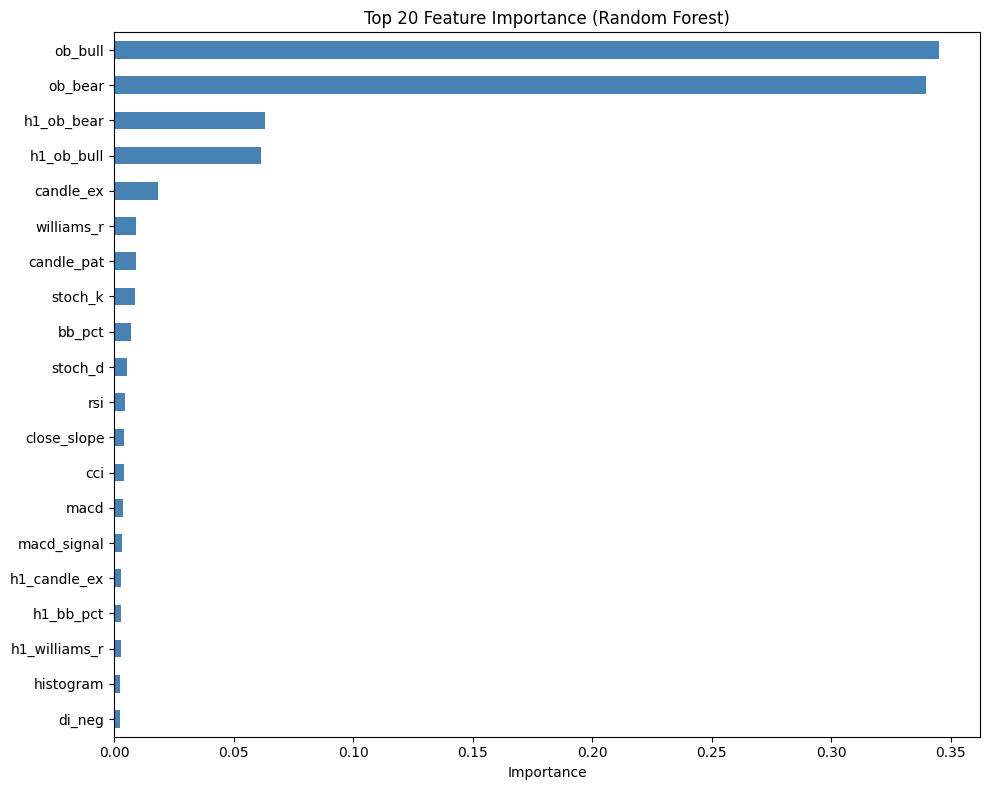

ob_bull          0.344997
ob_bear          0.339855
h1_ob_bear       0.063036
h1_ob_bull       0.061407
candle_ex        0.018547
williams_r       0.009123
candle_pat       0.008961
stoch_k          0.008831
bb_pct           0.007052
stoch_d          0.005412
rsi              0.004527
close_slope      0.004302
cci              0.004268
macd             0.003677
macd_signal      0.003297
h1_candle_ex     0.003038
h1_bb_pct        0.002783
h1_williams_r    0.002765
histogram        0.002658
di_neg           0.002428
dtype: float64

In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
top20 = importances.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 Feature Importance (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "feature_importance.png", dpi=120)
plt.show()

top20

## 9. Backtest hasil prediksi di test set — PnL riil, bukan cuma metrik ML

Metrik ML (accuracy/AUC) tidak otomatis berarti profitable. Simulasikan trading sungguhan: pakai
prediksi model sbg sinyal (dgn threshold probabilitas). **TP/SL simetris 1×ATR di tiap candle**
(konsisten dengan definisi label), bukan fixed TP12/SL6 seperti v02-v04 — supaya backtest benar-benar
mengukur akurasi arah yang diprediksi model, bukan tercampur efek RR asimetris.

**Kenapa pakai FIXED LOT 0.01, bukan compounding 1% risk seperti v02-v04:** run pertama notebook ini
pakai position sizing 1% equity. Dengan win rate tinggi, equity naik cepat, dan karena lot dihitung
ulang dari `equity * risk_pct` tiap trade, lot ikut membesar terus — hasil akhir: equity meledak ke
JUTAAN dolar dari modal $100 (lot sampai ribuan). Ini SECARA MATEMATIS valid tapi TIDAK REALISTIS:
broker retail makin besar lot makin butuh margin proporsional yg tidak dicek di simulasi ini, dan
likuiditas pasar riil terbatas. **Fixed lot menghilangkan efek compounding supaya yang terukur murni
edge sinyal model, bukan money-management yang agresif.**

In [11]:
INITIAL_EQUITY = 100.0
CONTRACT_SIZE = 100.0
FIXED_LOT = 0.01  # fixed, TIDAK compounding -- lihat catatan di atas kenapa
SPREAD_POINTS = 0.30
MAX_HOLD_CANDLES = 12


def backtest_ml_predictions(df_full: pd.DataFrame, test_index_positions: np.ndarray,
                             proba: np.ndarray, prob_threshold: float,
                             max_hold: int) -> tuple[pd.DataFrame, list]:
    """df_full = df ASLI (bukan df_ml) supaya candle setelah entry bisa dicek utk TP/SL,
    walau candle itu sendiri tidak dipakai sbg entry (mis. karena label NaN).
    TP/SL simetris 1xATR (kolom 'atr' di df_full), FIXED_LOT (bukan compounding)."""
    trades = []
    equity = INITIAL_EQUITY
    equity_curve = [equity]
    n = len(df_full)

    last_exit_i = -1
    for pos_in_test, i in enumerate(test_index_positions):
        if i <= last_exit_i:
            continue  # posisi masih terbuka dari trade sebelumnya, skip overlap

        p_buy = proba[pos_in_test]
        if p_buy >= prob_threshold:
            direction = "BUY"
        elif p_buy <= (1 - prob_threshold):
            direction = "SELL"
        else:
            continue  # tidak cukup yakin -> WAIT

        row = df_full.iloc[i]
        dist = row["atr"]
        if not np.isfinite(dist) or dist <= 0:
            continue

        entry_price = row["close"] + (SPREAD_POINTS if direction == "BUY" else -SPREAD_POINTS)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price, sl_price = entry_price + dist, entry_price - dist
        else:
            tp_price, sl_price = entry_price - dist, entry_price + dist

        lot = FIXED_LOT
        equity_before = equity

        exit_price, exit_time, exit_reason, exit_j = None, None, None, None
        for j in range(i + 1, min(i + 1 + max_hold, n)):
            candle = df_full.iloc[j]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price
            if hit_sl:
                exit_price, exit_time, exit_reason, exit_j = sl_price, candle["datetime"], "SL", j
                break
            if hit_tp:
                exit_price, exit_time, exit_reason, exit_j = tp_price, candle["datetime"], "TP", j
                break

        if exit_price is None:
            last_idx = min(i + max_hold, n - 1)
            last_candle = df_full.iloc[last_idx]
            exit_price, exit_time, exit_reason, exit_j = last_candle["close"], last_candle["datetime"], "TIMEOUT", last_idx

        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * lot * CONTRACT_SIZE
        equity += pnl
        equity_curve.append(equity)

        trades.append({
            "entry_time": entry_time, "exit_time": exit_time, "direction": direction,
            "entry_price": entry_price, "exit_price": exit_price, "lot": lot,
            "pnl": pnl, "result": "WIN" if pnl > 0 else "LOSS", "exit_reason": exit_reason,
            "prob_buy": p_buy, "equity_before": equity_before, "equity_after": equity,
        })
        last_exit_i = exit_j

    return pd.DataFrame(trades), equity_curve


def evaluate_trades(trades: pd.DataFrame, initial_equity: float) -> dict:
    if trades.empty:
        return {"total_trades": 0}
    wins = trades[trades["pnl"] > 0]
    losses = trades[trades["pnl"] <= 0]
    gross_profit = wins["pnl"].sum()
    gross_loss = losses["pnl"].sum()
    final_equity = trades["equity_after"].iloc[-1]
    equity_series = pd.Series([initial_equity] + trades["equity_after"].tolist())
    running_max = equity_series.cummax()
    drawdown = (equity_series - running_max) / running_max * 100
    trades = trades.copy()
    trades["trade_date"] = trades["entry_time"].dt.date
    daily_pnl = trades.groupby("trade_date")["pnl"].sum()
    return {
        "total_trades": len(trades),
        "win_rate_pct": round(len(wins) / len(trades) * 100, 2),
        "profit_factor": round(gross_profit / abs(gross_loss), 2) if gross_loss != 0 else float("inf"),
        "net_pnl": round(gross_profit + gross_loss, 2),
        "final_equity": round(final_equity, 2),
        "max_drawdown_pct": round(drawdown.min(), 2),
        "min_equity": round(equity_series.min(), 2),
        "trading_days": daily_pnl.shape[0],
        "avg_daily_pnl": round(daily_pnl.mean(), 2),
        "avg_trades_per_day": round(len(trades) / daily_pnl.shape[0], 2) if daily_pnl.shape[0] else 0,
    }

In [12]:
# Bangun lookup proba untuk VALIDATION (buat pilih threshold) dan TEST (buat evaluasi final)
def build_backtest_frame(period_df: pd.DataFrame, proba: np.ndarray,
                          start_date: str, end_date: str | None = None) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    lookup = period_df[["datetime"]].copy()
    lookup["prob_buy"] = proba
    mask = df["datetime"] >= start_date
    if end_date is not None:
        mask &= df["datetime"] < end_date
    full = df[mask].reset_index(drop=True)
    full = full.merge(lookup, on="datetime", how="left")
    positions = full.index[full["prob_buy"].notna()].to_numpy(dtype=np.int64)
    proba_aligned = full.loc[positions, "prob_buy"].to_numpy(dtype=np.float64)
    return full, positions, proba_aligned


df_bt_val, val_positions, val_proba_aligned = build_backtest_frame(val_df, val_proba, VAL_START, TEST_START)
print(f"Baris validation dgn prediksi: {len(val_positions):,}")

Baris validation dgn prediksi: 53,623


In [13]:
# Grid search threshold DI VALIDATION SET (2024) -- boleh, krn ini bukan test set final
prob_thresholds = [0.55, 0.60, 0.65, 0.70, 0.75]
val_grid_results = []

for thresh in prob_thresholds:
    trades, _ = backtest_ml_predictions(
        df_bt_val, val_positions, val_proba_aligned, thresh, MAX_HOLD_CANDLES,
    )
    m = evaluate_trades(trades, INITIAL_EQUITY)
    m["prob_threshold"] = thresh
    m["direction_breakdown"] = trades["direction"].value_counts().to_dict() if len(trades) else {}
    val_grid_results.append(m)
    print(f"threshold={thresh:.2f} -> trades={m.get('total_trades',0):5d} "
          f"win_rate={m.get('win_rate_pct',0):5.1f}% PF={m.get('profit_factor',0):5.2f} "
          f"avg_daily=${m.get('avg_daily_pnl',0):6.2f} trades/day={m.get('avg_trades_per_day',0):.2f} "
          f"dir={m['direction_breakdown']}")

val_grid_df = pd.DataFrame(val_grid_results)
val_grid_df

threshold=0.55 -> trades=12092 win_rate= 66.7% PF= 2.27 avg_daily=$ 29.76 trades/day=45.46 dir={'SELL': 6400, 'BUY': 5692}


threshold=0.60 -> trades=10067 win_rate= 67.4% PF= 2.34 avg_daily=$ 25.55 trades/day=37.85 dir={'SELL': 6179, 'BUY': 3888}


threshold=0.65 -> trades= 7452 win_rate= 66.5% PF= 2.25 avg_daily=$ 18.17 trades/day=28.12 dir={'SELL': 5205, 'BUY': 2247}


threshold=0.70 -> trades= 2195 win_rate= 69.2% PF= 2.70 avg_daily=$  6.81 trades/day=9.38 dir={'SELL': 1897, 'BUY': 298}
threshold=0.75 -> trades=   11 win_rate= 72.7% PF= 3.19 avg_daily=$  0.68 trades/day=1.10 dir={'BUY': 9, 'SELL': 2}


,total_trades,win_rate_pct,profit_factor,net_pnl,final_equity,max_drawdown_pct,min_equity,trading_days,avg_daily_pnl,avg_trades_per_day,prob_threshold,direction_breakdown
0,12092,66.66,2.27,7917.04,8017.04,-5.57,99.78,266,29.76,45.46,0.55,"{'SELL': 6400, 'BUY': 5692}"
1,10067,67.41,2.34,6796.90,6896.90,-12.94,90.32,266,25.55,37.85,0.60,"{'SELL': 6179, 'BUY': 3888}"
2,7452,66.53,2.25,4815.50,4915.50,-5.65,97.36,265,18.17,28.12,0.65,"{'SELL': 5205, 'BUY': 2247}"
3,2195,69.20,2.70,1592.44,1692.44,-2.94,98.13,234,6.81,9.38,0.70,"{'SELL': 1897, 'BUY': 298}"
4,11,72.73,3.19,6.76,106.76,-1.95,98.05,10,0.68,1.10,0.75,"{'BUY': 9, 'SELL': 2}"


## 10. Pilih threshold dari validation, evaluasi SEKALI di test set (2025-2026)

Threshold dipilih berdasar profit factor di **validation** (2024), dengan syarat minimum jumlah
trade (>=100) supaya tidak memilih threshold dengan sample terlalu kecil/noisy. Threshold ini lalu
diterapkan SEKALI ke test set (2025-2026) — tidak ada grid search lagi di sini, supaya angka yang
dilaporkan benar-benar out-of-sample murni.

In [14]:
# Pilih threshold terbaik dari VALIDATION (bukan test) dgn syarat minimum sample
val_candidates = val_grid_df[val_grid_df["total_trades"] >= 100].sort_values("profit_factor", ascending=False)
best_threshold = float(val_candidates.iloc[0]["prob_threshold"]) if len(val_candidates) else 0.60
print(f"Threshold terpilih dari validation: {best_threshold}")

# Hitung test_proba (belum ada sebelumnya krn evaluasi ML kita pindah ke validation)
test_proba = model.predict_proba(X_test)[:, 1]

df_bt_test, test_positions, test_proba_aligned = build_backtest_frame(test_df, test_proba, TEST_START)

trades_test, equity_curve_test = backtest_ml_predictions(
    df_bt_test, test_positions, test_proba_aligned, best_threshold, MAX_HOLD_CANDLES,
)
test_metrics = evaluate_trades(trades_test, INITIAL_EQUITY)
test_metrics["direction_breakdown"] = trades_test["direction"].value_counts().to_dict() if len(trades_test) else {}

print()
for k, v in test_metrics.items():
    print(f"{k:25s}: {v}")

Threshold terpilih dari validation: 0.7



total_trades             : 3484
win_rate_pct             : 77.04
profit_factor            : 3.79
net_pnl                  : 9155.19
final_equity             : 9255.19
max_drawdown_pct         : -4.54
min_equity               : 95.83
trading_days             : 427
avg_daily_pnl            : 21.44
avg_trades_per_day       : 8.16
direction_breakdown      : {'SELL': 3482, 'BUY': 2}


In [15]:
v04_metrics = {
    "total_trades": 1939, "win_rate_pct": 44.51, "profit_factor": 1.27, "net_pnl": 1601.34,
    "max_drawdown_pct": -37.02, "avg_daily_pnl": 4.02, "avg_trades_per_day": 4.87,
}

comparison = pd.DataFrame({
    "v04 rule-based (grid search @ test)": v04_metrics,
    f"v05 ML (threshold={best_threshold}, dipilih @ validation)": {k: test_metrics.get(k) for k in v04_metrics},
})
comparison

,v04 rule-based (grid search @ test),"v05 ML (threshold=0.7, dipilih @ validation)"
total_trades,1939.00,3484.00
win_rate_pct,44.51,77.04
profit_factor,1.27,3.79
net_pnl,1601.34,9155.19
max_drawdown_pct,-37.02,-4.54
avg_daily_pnl,4.02,21.44
avg_trades_per_day,4.87,8.16


**Catatan soal perbandingan ini:** v04 tetap dituning langsung memakai data 2025-2026 (in-sample
untuk periode itu). v05 sekarang benar-benar out-of-sample: model dilatih di 2019-2023, threshold
dipilih dari 2024 (validation), dan baris di atas adalah SEKALI evaluasi di 2025-2026 tanpa tuning
apa pun di periode itu. Ini perbandingan yang jauh lebih adil dari run pertama (yang threshold-nya
ikut di-cherry-pick dari test set, menghasilkan angka yang terlalu bagus/tidak realistis).

## 11. Simpan model, metadata, dan hasil

In [16]:
joblib.dump(model, MODEL_DIR / "random_forest.joblib", compress=3)

trades_test.to_csv(PROCESSED_OUT_DIR / "trade_log_full.csv", index=False)
val_grid_df.to_csv(EXPORT_DIR / "validation_threshold_grid.csv", index=False)
wf_df.to_csv(EXPORT_DIR / "walk_forward_results.csv", index=False)

metadata = {
    "model_name": STRATEGY_NAME,
    "version": VERSION,
    "symbol": "XAUUSD",
    "timeframe": "M5",
    "algorithm": "RandomForestClassifier",
    "created_at": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "source_notebook": "notebooks/m5_scalping/v05_ml_training.ipynb",
    "model_file": "random_forest.joblib",
    "hyperparameters": {
        "n_estimators": 300, "max_depth": 10, "min_samples_leaf": 50,
        "class_weight": "balanced", "random_state": RANDOM_STATE,
    },
    "features": FEATURE_COLS,
    "n_features": len(FEATURE_COLS),
    "label_definition": (
        f"TP=SL=1xATR (symmetric), lookahead={LOOKAHEAD} candle M5, "
        f"close-call margin<={CLOSE_CALL_MARGIN} candle dibuang, ambigu/timeout dibuang"
    ),
    "train_period": f"{train_df['datetime'].min()} to {train_df['datetime'].max()}",
    "validation_period": f"{val_df['datetime'].min()} to {val_df['datetime'].max()}",
    "test_period": f"{test_df['datetime'].min()} to {test_df['datetime'].max()}",
    "train_size": len(train_df),
    "validation_size": len(val_df),
    "test_size": len(test_df),
    "walk_forward_auc_mean": round(wf_df["auc"].mean(), 4),
    "walk_forward_auc_std": round(wf_df["auc"].std(), 4),
    "validation_accuracy": round(val_acc, 4),
    "validation_auc": round(val_auc, 4),
    "selected_prob_threshold": best_threshold,
    "threshold_selection_method": "grid search di VALIDATION set (2024), bukan test set",
    "test_metrics_out_of_sample": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                                     for k, v in test_metrics.items() if k != "direction_breakdown"},
    "test_direction_breakdown": test_metrics.get("direction_breakdown", {}),
    "trade_params": {
        "tp_sl": "symmetric 1xATR per candle (dinamis, bukan fixed poin)",
        "max_hold_candles": MAX_HOLD_CANDLES,
        "position_sizing": "FIXED_LOT (bukan compounding -- lihat catatan sebelum backtest)",
        "fixed_lot": FIXED_LOT, "spread_points_assumed": SPREAD_POINTS,
        "contract_size": CONTRACT_SIZE,
    },
    "notes": (
        "Model ML (bukan rule-based) untuk mengurangi risiko overfitting dari grid search manual "
        "v02-v04. RIWAYAT REVISI (3 iterasi sebelum versi final ini):\n"
        "(1) TP12/SL6 asimetris + threshold dipilih di test set + compounding 1% risk -> equity "
        "meledak ke jutaan dolar dari modal $100 (bug: lot tumbuh tanpa batas realistis).\n"
        "(2) Fixed lot (bug di atas diperbaiki), tapi win rate 78-88% & PF 5-12 masih janggal -> "
        "investigasi menemukan 99.8% trade adalah SELL, akibat label imbalance 78.8% SELL yang "
        "murni disebabkan geometri TP12/SL6 asimetris (SL 2x lebih dekat = 2x lebih gampang kena "
        "duluan), BUKAN krn XAUUSD genuinely bearish. Model belajar 'deteksi momentum SELL kuat', "
        "bukan arah dua sisi yang genuine.\n"
        "(3) VERSI INI: label diganti symmetric TP=SL=1xATR (ala quant-trader-ai CandlePredictor, "
        "alasan didokumentasikan sama: RR asimetris bikin label bias). Split 3-bagian dgn threshold "
        "HANYA dipilih dari validation (2024), dievaluasi SEKALI di test (2025-2026) tanpa tuning "
        "lagi -- supaya angka yang dilaporkan benar-benar out-of-sample, bukan data-snooped.\n"
        "Belum divalidasi di akun demo/live."
    ),
}

with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print("Model tersimpan ke:", MODEL_DIR / "random_forest.joblib")
print("Metadata tersimpan ke:", MODEL_DIR / "metadata.json")
print("Log trade & hasil grid:", PROCESSED_OUT_DIR, "|", EXPORT_DIR)

Model tersimpan ke: D:\Projects\robot-scalping\models\m5_scalping\v05\random_forest.joblib
Metadata tersimpan ke: D:\Projects\robot-scalping\models\m5_scalping\v05\metadata.json
Log trade & hasil grid: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v05 | D:\Projects\robot-scalping\dataset\exports\m5_scalping\v05
